In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_unstructured import UnstructuredLoader
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_huggingface import HuggingFaceEmbeddings
import glob
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing import TypedDict, List, Literal
import re
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langgraph.checkpoint.memory import MemorySaver
from langchain_tavily import TavilySearch
import glob

C:\Users\ajayn\AppData\Local\Temp\ipykernel_10232\2986379632.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [2]:
#file path
files = glob.glob("documents/**/*", recursive=True)
files

['documents\\Company_Policies.pdf',
 'documents\\Company_Profile.pdf',
 'documents\\Product_and_Pricing.pdf']

In [3]:
loader = UnstructuredLoader(files,chunking_strategy="by_title")    

In [4]:
docs = loader.load()

INFO: pikepdf C++ to Python logger bridge initialized


In [5]:
#splitter
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(docs)

In [6]:
#embedding models
# embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={"batch_size": 64, "normalize_embeddings": True}
)

INFO: No device provided, using cpu
INFO: HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO: Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/res

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/

In [7]:
#rertriever
retriever = FAISS.from_documents(chunks, embedding_model).as_retriever(search_type='similarity', search_kwargs={'k':4})

INFO: Loading faiss with AVX512 support.
INFO: Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
INFO: Loading faiss with AVX2 support.
INFO: Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
INFO: Loading faiss.
INFO: Successfully loaded faiss.


In [8]:
#model
llm  = ChatGroq(model="openai/gpt-oss-20b")

# 1. retrieval Decision : whether it requires external docs or it can answer in its own

In [9]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    #step 1: creating decision state to check if retrieval is needed
    need_retrieval: bool
    

In [10]:
#for structured output
class retrievalDecision(BaseModel):
    decision : bool

In [11]:
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Decide whether retrieval is needed to answer the question. "
            "Use the retrievalDecision tool and return only the structured result. "
            "Set decision=True if answering requires specific facts, citations, "
            "or information likely not in the model. Set decision=False for general "
            "explanations, definitions, or reasoning that does not need sources. "
            "If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(
    retrievalDecision)

In [12]:
def decide_retrieval(state: State):
    decision = should_retrieve_llm.invoke(decide_retrieval_prompt.format(question=state["question"]))
    return {"need_retrieval": decision.decision}

In [13]:
# generate direct : which will not retrieve any documents
def generate_direct(state: State):
    answer = llm.invoke(
        [
            (
                "system",
                "You are a helpful assistant. Answer the question based on your knowledge."
            ),
            ("human", f"Question: {state['question']}"),
        ]
    )
    return {"answer": answer.content}


In [14]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}


In [15]:
# function for deciding whether to retrieve or not
def whether_retrieve(state: State):
    if state['need_retrieval']:
        return 'retrieve'
    else :
        return 'generate_direct'

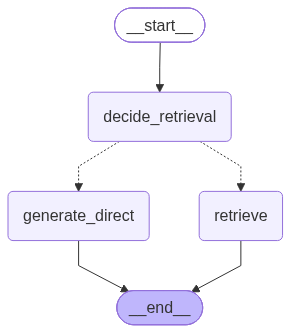

In [16]:
#build graph
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('generate_direct',END)
graph.add_edge('retrieve',END)

#compile
app = graph.compile()
app

In [17]:
result = app.invoke(
    {
        "question": 'who is the CEO of Nexa AI ?'
    }
)

print(result["need_retrieval"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


True


# 2. Creating relevant_docs as key in our State in case our model requires retrieval

In [18]:
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    need_retrieval: bool

    # step 2 : adding relevant_docs
    relevant_docs: List[Document]

In [19]:
# schema for judging docs
class judgeDocs(BaseModel):
    is_relevant : bool = Field(..., description="True if the document is relevant to the question, False otherwise.")

In [20]:
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance. "
            "Return only the provided structured output. "
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

#llm with relevance judgement output
relevance_judgement_llm = llm.with_structured_output(judgeDocs)

In [21]:
#now creating node for judging docs
def is_relevant(state: State):
    question = state["question"]
    docs = state['docs']
    #empty
    relevant_docs : List[Document] = []

    for doc in docs:
        relevant = relevance_judgement_llm.invoke(is_relevant_prompt.format(question=question, document=doc.page_content))
        if relevant.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

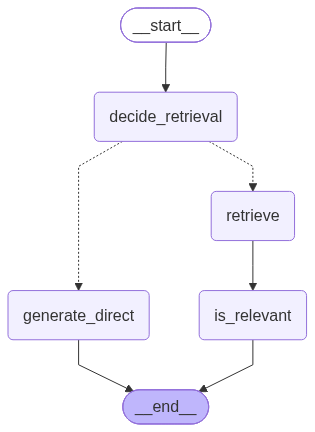

In [22]:
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
graph.add_edge('is_relevant',END)
graph.add_edge('generate_direct',END)


#compile
app = graph.compile()
app

In [23]:
result = app.invoke(
    {
        "question": 'who is the CEO of NexaAI ?'
    }
)

print(result["need_retrieval"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


True


In [24]:
#check relevant docs
print('\n'.join([i.page_content for i in  result['relevant_docs']]))

Founder

Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and cloud infrastructure.

He previously worked with global consulting firms where he led multiple large-scale digital transformation projects.

Leadership Team

The leadership team brings experience across AI engineering, product management, and business operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product


# 3. Generate from relevant docs

`Generating from relevant documents if available otherwise return "No relevant information found"`

In [25]:
# creating node : generate from context
def generate_from_context(state:State):
    #get question and relevant docs from state
    q = state['question']
    context = '\n'.join([i.page_content for i in state['relevant_docs']])

    #prompt
    prompt = ChatPromptTemplate.from_messages([
        ('system',
         "You are a helpful assistant, answer the following question using only provided context"),
         ('human',
          'Question : {question}\n\n context : {context}')
    ])
    # chain
    generate_from_context_chain  = prompt | llm

    #response
    response = generate_from_context_chain.invoke({'question':q, 'context':context})
    return {'answer': response.content}

In [26]:
# creating node called : no_relevant_docs
def no_relevant_docs(state:State):
    return {'answer':'No relevant information'}

In [27]:
# creating conditional edge function
def docsORnodocs(state:State):
    if state['relevant_docs']:
        return 'generate_from_context'
    else :
        return 'no_relevant_docs'

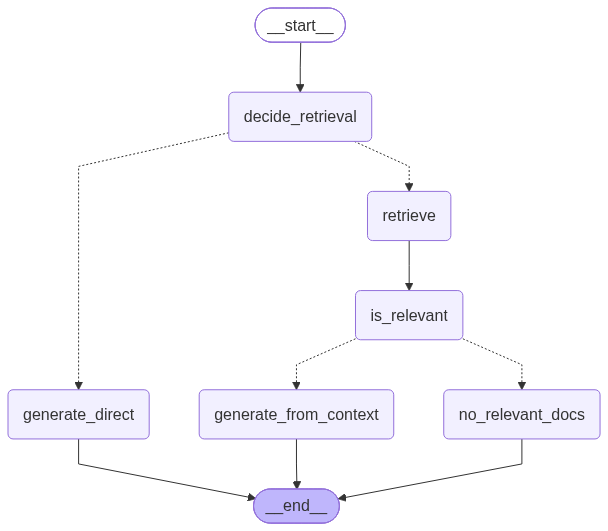

In [28]:
# build graph now
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)
graph.add_node('generate_from_context', generate_from_context)
graph.add_node('no_relevant_docs', no_relevant_docs)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
#step 3 is adding
graph.add_conditional_edges('is_relevant',docsORnodocs,{'generate_from_context': 'generate_from_context', 'no_relevant_docs': 'no_relevant_docs'})
graph.add_edge("generate_from_context", END)
graph.add_edge("no_relevant_docs", END)
#------------------------------------------

graph.add_edge('generate_direct',END)


#compile
app = graph.compile()
app

In [29]:
result = app.invoke(
    {
        "question": 'who is the CEO of NexaAI ?'
    }
)

print(result["answer"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The CEO of NexaAI is Aarav Mehta.


In [30]:
result = app.invoke(
    {
        "question": 'who is CEO of apple in 2026?'
    }
)

print(result["answer"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


No relevant information


# 4. Creating "is_sup" node after generating_from_context

`which will check if our generated context is sufficient to answer the question also it will`

In [31]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    need_retrieval: bool
    relevant_docs: List[Document]

    #step 4
    is_hallucinating : bool
    is_supporting : str

In [32]:
# creating pydantic schema
class is_suff_schema(BaseModel):
    answer : Literal['fully_supported', 'partially_supported', 'no_supported']
    is_hallucinating : bool = Field(description="Whether the answer is hallucinating or not")
    

In [33]:
is_suff_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are a question and answer supervisor. Evaluate how well the generated answer is supported by the provided context.\n\n'
     'Return one of these values for the "answer" field:\n'
     '- fully_supported: when the context contains all information needed to answer the question and the generated answer is accurate based on the context\n'
     '- partially_supported: when the context has some relevant information but is incomplete or the answer has some unsupported details\n'
     '- no_supported: when the context does not contain information to answer the question or the answer contradicts the context\n\n'
     'For is_hallucinating:\n'
     '- True: if the answer contains information not present in the context or makes claims unsupported by the context\n'
     '- False: if the answer is fully derived from the provided context'),
     ('human',
      "Question: {question}\n\nContext: {context}\n\nGenerated Answer: {answer}")
])

#llm with structured output
is_suff_llm = is_suff_prompt | llm.with_structured_output(is_suff_schema)

In [34]:
# def creating is_suff node
def is_suff(state:State):
    question = state['question']
    answer = state['answer']
    context = '\n'.join([i.page_content for i in state['relevant_docs']])

    #output
    res = is_suff_llm.invoke({'question':question,'answer':answer, 'context':context})

    return {'is_supporting': res.answer,
            'is_hallucinating': res.is_hallucinating }

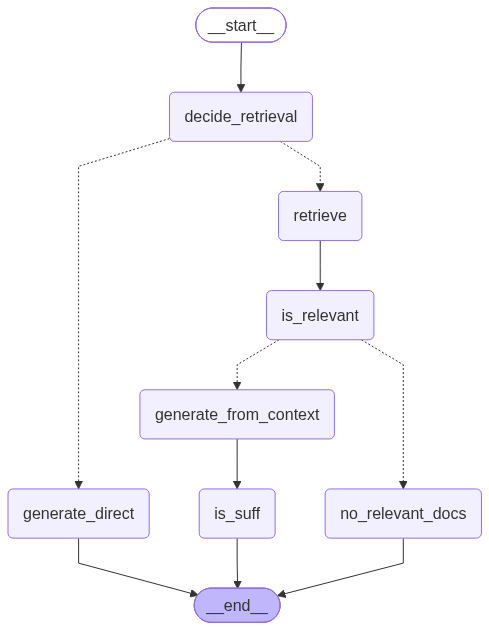

In [35]:
# build graph now
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)
graph.add_node('generate_from_context', generate_from_context)
graph.add_node('no_relevant_docs', no_relevant_docs)
graph.add_node('is_suff',is_suff)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
#step 3 is adding
graph.add_conditional_edges('is_relevant',docsORnodocs,{'generate_from_context': 'generate_from_context', 'no_relevant_docs': 'no_relevant_docs'})
#step 4 : is_sufficient
graph.add_edge("generate_from_context", 'is_suff')
graph.add_edge('is_suff', END)
graph.add_edge("no_relevant_docs", END)
#------------------------------------------

graph.add_edge('generate_direct',END)


#compile
app = graph.compile()
app

In [36]:
result = app.invoke(
    {
        "question": 'who is the CEO of NexaAI ?'
    }
)

print("Answer:", result["answer"])
print("is_supporting:", result["is_supporting"])
print("is_hallucinating:", result["is_hallucinating"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Answer: The CEO of NexaAI is **Aarav Mehta**.
is_supporting: fully_supported
is_hallucinating: False


In [37]:
result = app.invoke(
    {
        "question": "Describe NexaAI's company culture"
    }
)

print("Answer:", result["answer"])
print("is_supporting:", result["is_supporting"])
print("is_hallucinating:", result["is_hallucinating"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Answer: NexaAI’s company culture is built around fairness, inclusion, and high performance.  The organization emphasizes:

* **Equal opportunity and non‑discrimination** – all hiring and advancement decisions are made without bias.  
* **Clear career progression** – a structured framework guides employees from entry to senior roles.  
* **Performance‑driven focus** – bi‑annual reviews assess growth and set goals.  
* **Zero tolerance for harassment** – a strict anti‑harassment policy protects every team member.  
* **Work‑life balance** – employees are encouraged to maintain healthy boundaries, with 18 paid working days of annual leave.  

Together, these policies foster an environment where employees feel respected, motivated, and supported in both their professional development and personal well‑being.
is_supporting: fully_supported
is_hallucinating: False


# 5. Adding Web Search Node

`adding web_search node which will search on internet about the question`

In [38]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    need_retrieval: bool
    relevant_docs: List[Document]
    is_hallucinating : bool
    is_supporting : str

    #step 5 : web search
    web_searched : bool
    refined_query : str

In [39]:
#we also need to make a query refiner which will refine user's query before searching on the web so we get more accurate results
class queryRefiner(BaseModel):
    refined_query : str

query_prompt = ChatPromptTemplate.from_messages([(
    'system',
    "You are a query refiner. Refine the user query to make it more specific and relevant for web search.\n"),(
        'human',
        "Question : {question}"
)])

In [40]:
# web Search Node
def webSearch(state : State):
    question = state['question']

    #refining the query to get more relevant results
    refined_query = (query_prompt | llm.with_structured_output(queryRefiner)).invoke({'question': question}).refined_query

    #searching the web using TavilySearch
    web  = TavilySearch()
    web_res = web.invoke(refined_query, max_results=3)
    return {'docs': [Document(i['content']) for i in web_res['results']],
            'web_searched' : True,
            'refined_query': refined_query}

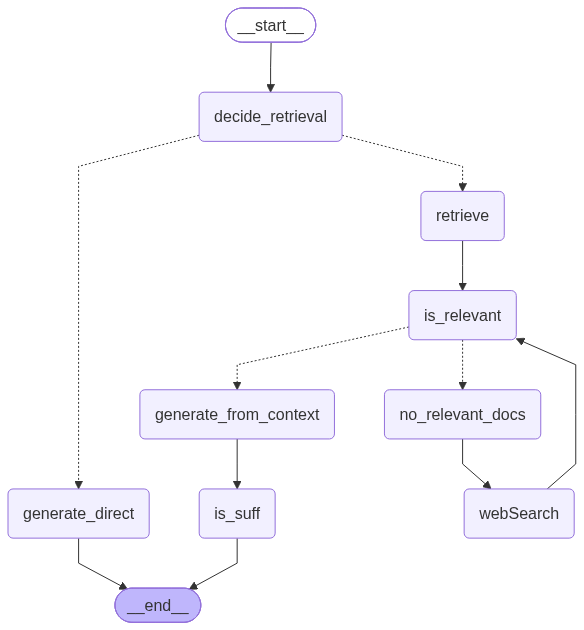

In [41]:
# build graph now
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)
graph.add_node('generate_from_context', generate_from_context)
graph.add_node('no_relevant_docs', no_relevant_docs)
graph.add_node('is_suff',is_suff)
graph.add_node('webSearch', webSearch)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
#step 3 is adding
graph.add_conditional_edges('is_relevant',docsORnodocs,{'generate_from_context': 'generate_from_context', 'no_relevant_docs': 'no_relevant_docs'})
#step 4 : is_sufficient
graph.add_edge("generate_from_context", 'is_suff')
graph.add_edge('is_suff', END)
#step 5: web search after no_relevant_docs
graph.add_edge("no_relevant_docs", 'webSearch')
graph.add_edge('webSearch', 'is_relevant')
graph.add_edge('generate_direct',END)


#compile
app = graph.compile()
app

In [42]:
result = app.invoke(
    {
        "question": "why real madrid's last matches were disaster? Why the club is performing very poor? "
    }
)

print("Answer:", result["answer"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO: Retrying request to /openai/v1/chat/completions in 2.000000 seconds
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
I

Answer: Real Madrid’s recent slump is the result of a handful of intertwined problems that the article lays out quite clearly:

1. **Injury‑heavy squad**  
   - Key players have been sidelined for long periods: Thibaut Courtois, Eder Militao, David Alaba, Dani Carvajal (ACL injuries), and the loss of Toni Kroos to retirement.  
   - The club still feels the absence of those players, especially in defence, where the back‑line has been “lacklustre” and vulnerable to early goals (e.g., the 30‑second loss to Las Palmas).

2. **Defensive decline**  
   - Compared with last season, Madrid has conceded 31 goals in 32 league games (0.97 goals per game) versus 26 in 38 last season (0.68).  
   - This drop in defensive solidity means the team often has to chase the game, leaving them exposed at the back.

3. **Lack of clinical finishing**  
   - In the last two high‑profile matches (Bayern Munich and Girona) the team created plenty of chances but failed to convert them into goals.  
   - The art

In [43]:
result.keys()

dict_keys(['question', 'docs', 'answer', 'need_retrieval', 'relevant_docs', 'is_hallucinating', 'is_supporting', 'web_searched', 'refined_query'])

In [44]:
print(f"Question :{result['question']}\n                                    vs\nRefined Question : {result['refined_query']}")

Question :why real madrid's last matches were disaster? Why the club is performing very poor? 
                                    vs
Refined Question : Why has Real Madrid performed poorly in recent matches? Analysis of last games, key factors, injuries, tactical changes, and managerial impact.


# 6. Connecting is_suff node to web_search Node

`in case if context and generated answer is not enough i.e 'partially supporting' or 'not supporting' we will go to web search node`,

In [45]:
#creating a function for checking if answer fully supporting or not
def check_answer(state : State):
    if state['is_supporting'] in ['partially_supported','partially_supported']:
        return 'web_search'
    else :
        return 'END'
    

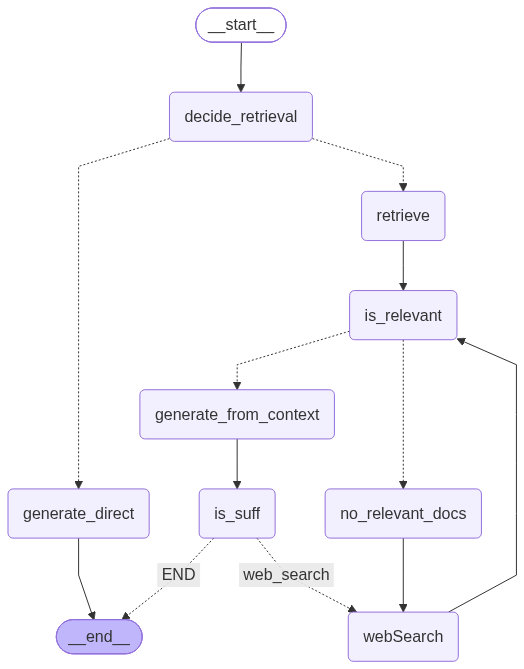

In [ ]:
# build graph now
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)
graph.add_node('generate_from_context', generate_from_context)
graph.add_node('no_relevant_docs', no_relevant_docs)
graph.add_node('is_suff',is_suff)
graph.add_node('webSearch', webSearch)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
#step 3 is adding
graph.add_conditional_edges('is_relevant',docsORnodocs,{'generate_from_context': 'generate_from_context', 'no_relevant_docs': 'no_relevant_docs'})
#step 4 : is_sufficient
graph.add_edge("generate_from_context", 'is_suff')

#step 6 : going to web search if generated answer is not sufficient
graph.add_conditional_edges('is_suff', check_answer, {'web_search': 'webSearch','END' : END})

#step 5: web search after no_relevant_docs
graph.add_edge("no_relevant_docs", 'webSearch')
graph.add_edge('webSearch', 'is_relevant')
graph.add_edge('generate_direct',END)

#compile
app = graph.compile()
app

In [47]:
result = app.invoke(
    {
        "question": "give me all the topics of all the info we have about and the info we do not have about NexaAi companpy "
    }
)

print("Answer:", result["answer"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Answer: **Topics we *have* information about NexaAI:**

| Category | Specifics in the context |
|----------|--------------------------|
| **Company Overview** | Founded 2021, headquartered in Bengaluru, India, 85+ employees, serves mid‑size & large orgs in tech, finance, healthcare, education |
| **Products & Pricing** | Modular enterprise AI suite for knowledge management, analytics, automation, and governance (generic overview, no specific pricing tiers) |
| **Founder** | Aarav Mehta, 10+ years in enterprise data platforms & cloud infra, prior consulting experience |
| **Leadership Team** | CEO & Founder – Aarav Mehta; CTO – Riya Kapoor (distributed systems & AI platforms); Head of Product – Kunal Sharma |
| **HR Policies** | Fair, inclusive, performance‑driven workplace; non‑discriminatory hiring; equal‑opportunity employer; bi‑annual performance reviews; clear career progression; strict anti‑harassment policy |
| **Leave Policy** | 18 working days of annual leave per year |

---

*

In [54]:
#now let's check about the topic about NexaAi that we do not have : may be we get partially supported answer
result = app.invoke(
    {
        "question": "tell me about the AI governance specifics of NexaAi company"
    }
)

print("Answer:", result["answer"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Answer: **NexaAI’s AI Governance – NexaSecure**

NexaAI’s dedicated governance component, **NexaSecure**, is the cornerstone of the company’s approach to responsible, compliant AI deployment. It adds a robust, auditable layer that protects sensitive data and ensures that every AI interaction meets regulatory and internal policy requirements.

Key specifics:

| Feature | Description |
|---------|-------------|
| **Role‑based access & document permissions** | Controls who can use, modify, or view AI models and the data they process. Permissions are tied to user roles, ensuring that only authorized personnel can execute or influence AI workflows. |
| **Query logging & audit trails** | Every request sent to an AI model is recorded with full metadata (user, time, input, output, model version). These logs form a comprehensive audit trail that can be reviewed for compliance checks, incident investigations, or regulatory reporting. |
| **Secure, compliant, auditable usage** | By combining gran

In [56]:
result.keys()

dict_keys(['question', 'docs', 'answer', 'need_retrieval', 'relevant_docs', 'is_hallucinating', 'is_supporting'])

In [57]:
result['is_supporting']

'fully_supported'